# External Model Usage Example

This notebook demonstrates how to use a model class **defined outside of the Hyrax package** within Hyrax's training and inference pipeline. It covers:

- Registering an external model (`VGG11`) with Hyrax via the `@hyrax_model` decorator
- Overriding default model configuration parameters at runtime
- Training the external model using Hyrax's built-in CIFAR-10 dataset
- Running inference and evaluating classification performance with a confusion matrix

In [1]:
from hyrax import Hyrax

h = Hyrax()

## Configure the Model

To use an externally defined model, set `model.name` to the fully-qualified class path of your model. Hyrax will import and instantiate it automatically — the only requirement is that the class is decorated with `@hyrax_model`.

Here we also override one of the model's defaults: `batch_norm` is `False` by default in the config, and we enable it here to demonstrate that individual model parameters can be tuned at runtime.

In [ ]:
h.set_config("model.name", "external_hyrax_example.models.vgg11.VGG11")
h.set_config("external_hyrax_example.VGG11.batch_norm", True)

## Configure the Training Data

We'll use `HyraxCifarDataset`, a built-in Hyrax dataset that wraps the CIFAR-10 benchmark. Setting `split_fraction: 1.0` means the full training split (50k images) is used for training with no held-out validation set.

In [ ]:
data_request = {
    "train": {
        "data": {
            "dataset_class": "HyraxCifarDataset",
            "data_location": "./data",
            "fields": ["image", "label"],
            "primary_id_field": "object_id",
            "split_fraction": 1.0,
        },
    },
}
h.set_config("data_request", data_request)

Train the model. Hyrax handles the full training loop, including batching, loss computation, and result logging.

In [ ]:
model = h.train()

## Run Inference

Now we configure Hyrax for inference on the CIFAR-10 test set. We set `use_training_data: False` to tell the dataset to load the held-out test split (10k images). Note that `fields` no longer includes `"label"` — we're only requesting images since labels aren't needed during inference.

In [ ]:
data_request = {
    "infer": {
        "data": {
            "dataset_class": "HyraxCifarDataset",
            "data_location": "./data",
            "fields": ["image"],
            "primary_id_field": "object_id",
            "dataset_config": {
                "HyraxCifarDataset": {
                    "use_training_data": False,
                },
            },
        },
    },
}
h.set_config("data_request", data_request)

In [ ]:
results = h.infer()

## Evaluate Performance

Each inference result is a 10-element vector of class logits, where the index of the largest value is the model's predicted class. We extract these predicted classes from the results returned by `h.infer()`.

In [12]:
# get the index of the maximum predicted class for all test samples
import numpy as np

predicted_classes = np.zeros(len(results)).astype(int)
for i in range(len(results)):
    predicted_classes[i] = results[i].argmax()

Load the CIFAR-10 test batch to retrieve the ground-truth labels for comparison.

In [ ]:
import pickle

with open("./data/cifar-10-batches-py/test_batch", "rb") as f_in:
    test_data = pickle.load(f_in, encoding="bytes")

Finally, we compute overall accuracy and display a confusion matrix using scikit-learn. The confusion matrix shows how often each true class was predicted as each other class, making it easy to spot where the model struggles.


Accuracy for test dataset: 0.737


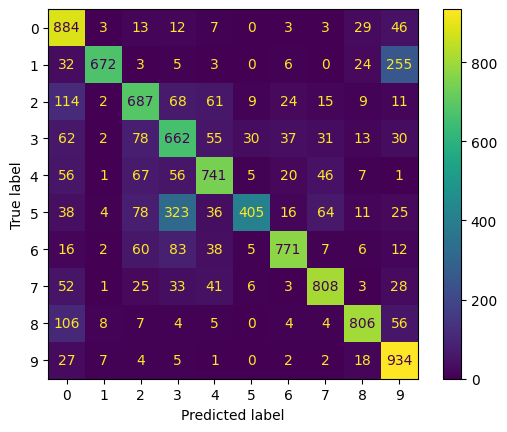

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_true = test_data[b"labels"]
y_pred = predicted_classes.tolist()

correct = 0
for t, p in zip(y_true, y_pred):
    correct += t == p

print("\nAccuracy for test dataset:", correct / len(y_true))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()